In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
x = np.array([1, 2, 3, 5, 6, 8, 10, 11])
y = 2 + 1.5*x + np.random.normal(0,1, size=x.shape)

In [4]:
x

array([ 1,  2,  3,  5,  6,  8, 10, 11])

In [6]:
x.shape

(8,)

In [5]:
y

array([ 3.99671415,  4.8617357 ,  7.14768854, 11.02302986, 10.76584663,
       13.76586304, 18.57921282, 19.26743473])

In [7]:
b0, b1 = -4.0, -1.0
learning_rate = 0.01
iterations = 50
history = []

In [ ]:
def rss(b0, b1, x, y):
  rss = 0
  for i in range(len(x)):
    rss += y[i] - (b0 + b1*x)**2
  return rss

In [ ]:
for _ in range(iterations):
  error = y - (b0 + b1*x)
  rss = np.sum(error**2)
  history.append([b0, b1, rss])

  grad_b0 = -2 * np.sum(error)
  grad_b1 = -2 * np.sum(error * x)

  b0 -= learning_rate * grad_b0
  b1 -= learning_rate * grad_b1

In [ ]:
beta0_range = np.linspace(-5, 10, 50)
beta1_range = np.linspace(-2, 5, 50)
B0, B1 = np.meshgrid(beta0_range, beta1_range)

In [ ]:
Z = np.zeros(B0.shape)
for i in range(B0.shape[0]):
  for j in range(B0.shape[1]):
    b0_val = B0[i, j]
    b1_val = B1[i, j]
    # Correct calculation of Residual Sum of Squares
    current_rss = np.sum((y - (b0_val + b1_val * x))**2)
    Z[i, j] = current_rss

In [ ]:
Z = np.array([[np.sum((y - (b0_val + b1_val * x))**2)
                      for b0_val in beta0_range] for b1_val in beta1_range])

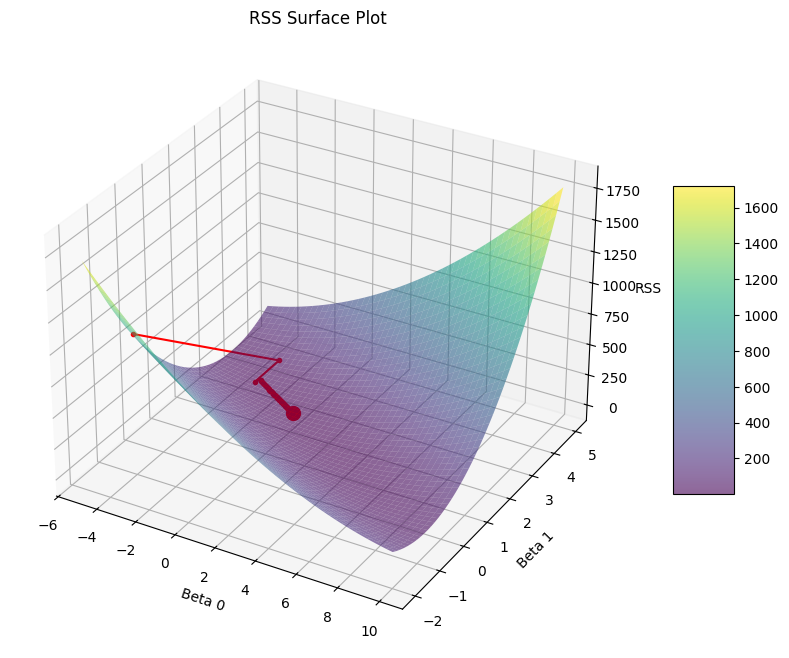

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(B0, B1, Z, cmap='viridis', alpha=0.6)

ax.plot(history[:, 0], history[:, 1], history[:, 2], color='red', marker = 'o', markersize = 3, label = 'GD Path')

ax.scatter(history[-1, 0], history[-1, 1], history[-1, 2], color='red', s=100)

ax.set_xlabel('Beta 0')
ax.set_ylabel('Beta 1')
ax.set_zlabel('RSS')
ax.set_title('RSS Surface Plot')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

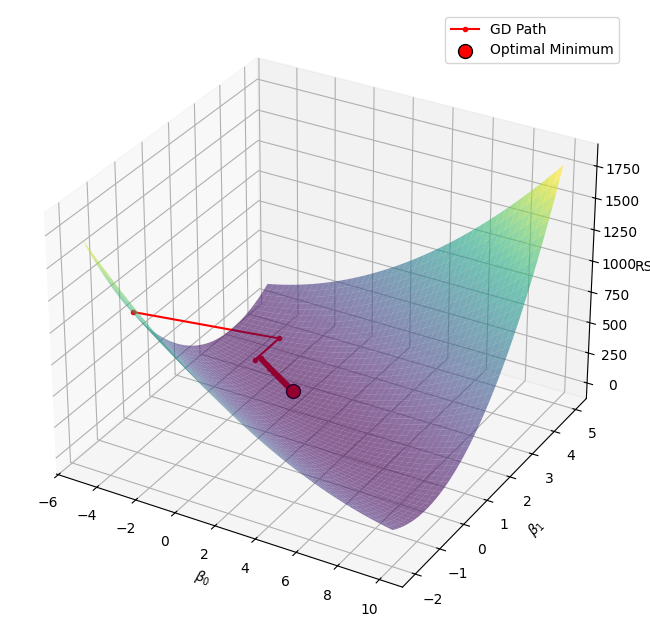

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5])
y = 2 + 1.5 * x + np.random.normal(0, 0.5, size=x.shape)

# 2. Gradient Descent Parameters
b0, b1 = -4.0, -1.0  # Starting point
learning_rate = 0.01
iterations = 50
history = []

# 3. Optimization Loop
for _ in range(iterations):
    error = y - (b0 + b1 * x)
    rss = np.sum(error**2)
    history.append([b0, b1, rss])

    # Partial derivatives
    grad_b0 = -2 * np.sum(error)
    grad_b1 = -2 * np.sum(error * x)

    # Update weights
    b0 -= learning_rate * grad_b0
    b1 -= learning_rate * grad_b1

history = np.array(history)

# 4. Create Grid for Surface
b0_grid = np.linspace(-5, 10, 50)
b1_grid = np.linspace(-2, 5, 50)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
Z = np.array([[np.sum((y - (b0_val + b1_val * x))**2)
               for b0_val in b0_grid] for b1_val in b1_grid])

# 5. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the RSS Surface
ax.plot_surface(B0, B1, Z, cmap='viridis', alpha=0.6)

# Plot the Gradient Descent path (in red)
ax.plot(history[:, 0], history[:, 1], history[:, 2], color='red', marker='o', markersize=3, label='GD Path')

# Mark the Lowest Point (Last iteration)
ax.scatter(history[-1, 0], history[-1, 1], history[-1, 2], color='red', s=100, edgecolors='black', label='Optimal Minimum')

ax.set_xlabel(r'$\beta_0$')
ax.set_ylabel(r'$\beta_1$')
ax.set_zlabel('RSS')
ax.legend()
plt.show()
